In [12]:
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv('/Users/norman/Downloads/W2_Superstore_Sales.csv', index_col=0)
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')
df['Ship_Date'] = pd.to_datetime(df['Ship_Date'], errors='coerce')
df['Order_Year'] = df['Order_Date'].dt.year
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 9789 entries, 0 to 9799
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row_ID         9789 non-null   int64         
 1   Order_ID       9789 non-null   object        
 2   Order_Date     9789 non-null   datetime64[ns]
 3   Ship_Date      9789 non-null   datetime64[ns]
 4   Ship_Mode      9789 non-null   object        
 5   Customer_ID    9789 non-null   object        
 6   Customer_Name  9789 non-null   object        
 7   Segment        9789 non-null   object        
 8   Country        9789 non-null   object        
 9   City           9789 non-null   object        
 10  State          9789 non-null   object        
 11  Postal_Code    9789 non-null   int64         
 12  Region         9789 non-null   object        
 13  Product_ID     9789 non-null   object        
 14  Category       9789 non-null   object        
 15  Sub_Category   9789 non-nu

In [10]:
years = df[df['Order_Year'].between(2015, 2018)]
total_sales = years['Sales'].sum()
print(f'The total sales between Year 2015-2018 is {total_sales:.2f} USD.')

The total sales between Year 2015-2018 is 2252607.41 USD.


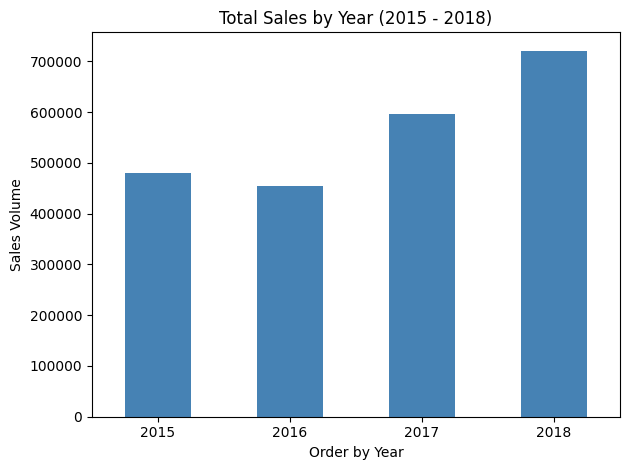

In [13]:
sales_year = years.groupby('Order_Year')['Sales'].sum()

sales_year.plot(kind='bar', color='steelblue')
plt.title('Total Sales by Year (2015 - 2018)')
plt.xlabel('Order by Year')
plt.ylabel('Sales Volume')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Category
Office Supplies    5903
Furniture          2076
Technology         1810
Name: Sales, dtype: int64

Highest no. of orders: Office Supplies (5903 orders)


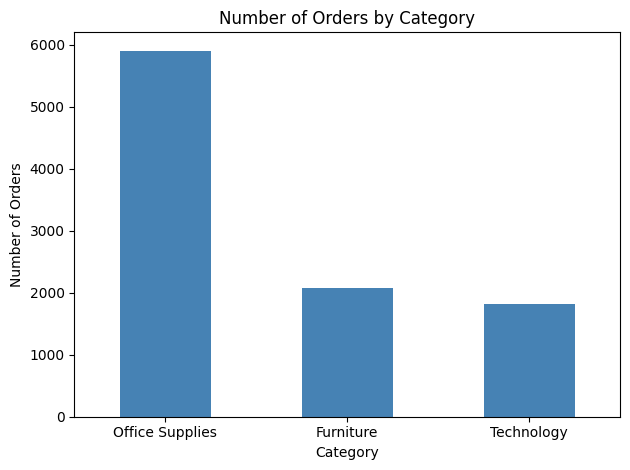

In [18]:
category_count = df.groupby('Category')['Sales'].count().sort_values(ascending=False)
print(category_count)
print(f'\nHighest no. of orders: {category_count.idxmax()} ({category_count.max()} orders)')

category_count.plot(kind='bar', color='steelblue')
plt.title('Number of Orders by Category')
plt.xlabel('Category')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Category
Furniture          723538.4757
Office Supplies    703212.8240
Technology         825856.1130
Name: Sales, dtype: float64

Highest sales volume: Technology ($825856.11)


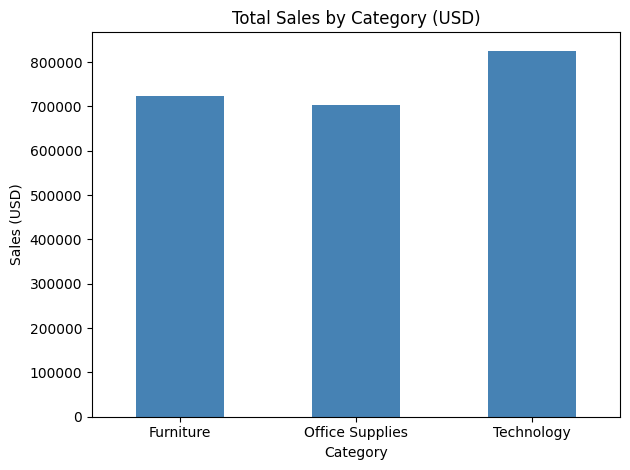

In [15]:
category_sales = df.groupby('Category')['Sales'].sum()
print(category_sales)
print(f'\nHighest sales volume: {category_sales.idxmax()} (${category_sales.max():.2f})')

category_sales.plot(kind='bar', color='steelblue')
plt.title('Total Sales by Category (USD)')
plt.xlabel('Category')
plt.ylabel('Sales (USD)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

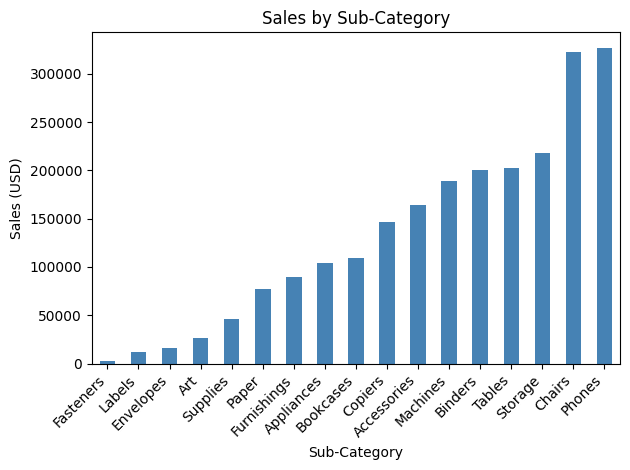

In [16]:
sub_sales = df.groupby('Sub_Category')['Sales'].sum().sort_values()

sub_sales.plot(kind='bar', color='steelblue')
plt.title('Sales by Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Sales (USD)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

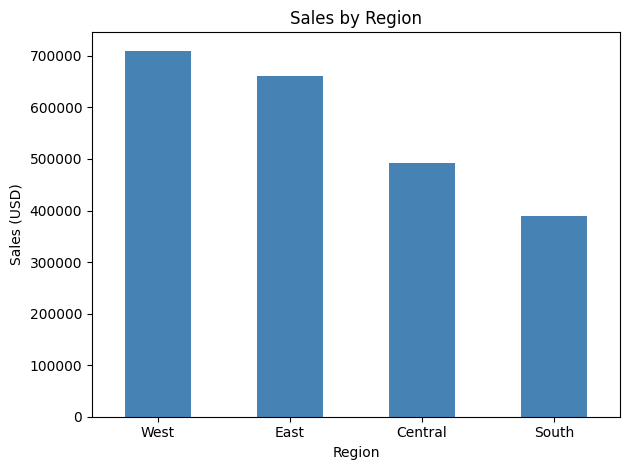

In [17]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

region_sales.plot(kind='bar', color='steelblue')
plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales (USD)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [19]:
city_sales = df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(10)
print(city_sales.reset_index().to_string(index=False))

         City       Sales
New York City 252462.5470
  Los Angeles 173420.1810
      Seattle 116106.3220
San Francisco 109041.1200
 Philadelphia 108841.7490
      Houston  63956.1428
      Chicago  47820.1330
    San Diego  47521.0290
 Jacksonville  44713.1830
      Detroit  42446.9440
